# Análisis exploratorio de una base de datos de películas

Usa la base de datos `./data/imdb.csv`


### 1. Importar `pandas`, `matplotlib` y `numpy`

In [ ]:
import pandas as pd

### 2. Leer la base de datos del archivo csv a pandas

In [ ]:
df = pd.read_csv('data/imdb.csv')

### 3. Mostrar las  primeras y últimas filas del dataframe. Hacerlo con el valor default y pasando como argumento el número entero de filas que se deseen inspeccionar.

In [ ]:
df.head(), df.tail()

(   Rank                    Title                     Genre  \
 0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
 1     2               Prometheus  Adventure,Mystery,Sci-Fi   
 2     3                    Split           Horror,Thriller   
 3     4                     Sing   Animation,Comedy,Family   
 4     5            Suicide Squad  Action,Adventure,Fantasy   
 
                                          Description              Director  \
 0  A group of intergalactic criminals are forced ...            James Gunn   
 1  Following clues to the origin of mankind, a te...          Ridley Scott   
 2  Three girls are kidnapped by a man with a diag...    M. Night Shyamalan   
 3  In a city of humanoid animals, a hustling thea...  Christophe Lourdelet   
 4  A secret government agency recruits some of th...            David Ayer   
 
                                               Actors  Year  Runtime (Minutes)  \
 0  Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...  2014   

### 4. Continúa inspeccionando el archivo viendo todas las columnas del dataframe

In [ ]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='str')

### 5. Imprime los primeros valores de la variable `Rank`

In [ ]:
df.Rank.head()

0    1
1    2
2    3
3    4
4    5
Name: Rank, dtype: int64

### 6. Demuestra que es mejor tener nombres de columnas sin espacios (notación corchetes y notación punto-variable).

In [ ]:


df['Rank'].head()

df.Rank.head()


0    1
1    2
2    3
3    4
4    5
Name: Rank, dtype: int64

### 7. Renombra las columnas que tengan espacios

In [ ]:
df.rename(columns={'Runtime (Minutes)': 'Runtime_minutes'}, inplace=True)
df.rename(columns={'Revenue (Millions)': 'Revenue_millions'}, inplace=True)

In [ ]:
# o df = df.rename(columns={'Runtime (Minutes)': 'Runtime_minutes'})


### 8. Utiliza tus nuevas columnas sin espacios :)

In [ ]:
df.columns = df.columns.str.replace(' ', '_')
df.columns


Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime_minutes', 'Rating', 'Votes', 'Revenue_millions', 'Metascore'],
      dtype='str')

### 9. Visualiza la info de todo tu dataframe

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              1000 non-null   int64  
 1   Title             1000 non-null   str    
 2   Genre             1000 non-null   str    
 3   Description       1000 non-null   str    
 4   Director          1000 non-null   str    
 5   Actors            1000 non-null   str    
 6   Year              1000 non-null   int64  
 7   Runtime_minutes   1000 non-null   int64  
 8   Rating            1000 non-null   float64
 9   Votes             1000 non-null   int64  
 10  Revenue_millions  872 non-null    float64
 11  Metascore         936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB


### 10. Inspecciona si hay columnas que tengan valores `NA`

In [ ]:
df.isnull().sum()

Rank                  0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime_minutes       0
Rating                0
Votes                 0
Revenue_millions    128
Metascore            64
dtype: int64

### 11. Imprime el número total de valores NA que haya en cada columna. Hazlo primero para la columna `Metascore` y después utiliza un ciclo for para hacerlo para todas las columnas

In [ ]:
df.Metascore.isnull().sum()
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum()}')

Rank: 0
Title: 0
Genre: 0
Description: 0
Director: 0
Actors: 0
Year: 0
Runtime_minutes: 0
Rating: 0
Votes: 0
Revenue_millions: 128
Metascore: 64


### 12. Usa la magia de `dropna()`

In [ ]:
df.dropna(inplace=True)

### 13. Vuelve a ver la info del dataset

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 838 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              838 non-null    int64  
 1   Title             838 non-null    str    
 2   Genre             838 non-null    str    
 3   Description       838 non-null    str    
 4   Director          838 non-null    str    
 5   Actors            838 non-null    str    
 6   Year              838 non-null    int64  
 7   Runtime_minutes   838 non-null    int64  
 8   Rating            838 non-null    float64
 9   Votes             838 non-null    int64  
 10  Revenue_millions  838 non-null    float64
 11  Metascore         838 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 85.1 KB


### 14. Genera estadísticos descriptivos con el método `describe()`

In [ ]:
df.describe()

,Rank,Year,Runtime_minutes,Rating,Votes,Revenue_millions,Metascore
count,838.000000,838.00000,838.000000,838.000000,8.380000e+02,838.000000,838.000000
mean,485.247017,2012.50716,114.638425,6.814320,1.932303e+05,84.564558,59.575179
std,286.572065,3.17236,18.470922,0.877754,1.930990e+05,104.520227,16.952416
min,1.000000,2006.00000,66.000000,1.900000,1.780000e+02,0.000000,11.000000
25%,238.250000,2010.00000,101.000000,6.300000,6.127650e+04,13.967500,47.000000
50%,475.500000,2013.00000,112.000000,6.900000,1.368795e+05,48.150000,60.000000
75%,729.750000,2015.00000,124.000000,7.500000,2.710830e+05,116.800000,72.000000
max,1000.000000,2016.00000,187.000000,9.000000,1.791916e+06,936.630000,100.000000


### 15. Crea un histograma de la variable Metascore. Utiliza 10 cubetas

Help on function hist in module matplotlib.pyplot:

hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution ei

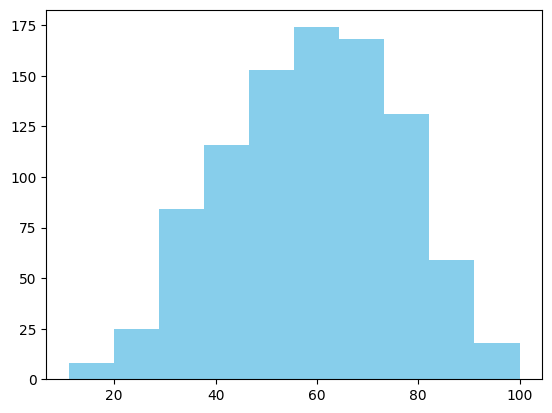

In [ ]:
import matplotlib.pyplot as plt 
plt.hist(df.Metascore, bins=10, color='skyblue')
help(plt.hist)


### 16. Crea un histograma de la variable Rating. Utiliza 10 cubetas

(array([  1.,   3.,   8.,  20.,  55., 154., 283., 281., 172.,  23.]),
 array([1.9 , 2.61, 3.32, 4.03, 4.74, 5.45, 6.16, 6.87, 7.58, 8.29, 9.  ]),
 <BarContainer object of 10 artists>)

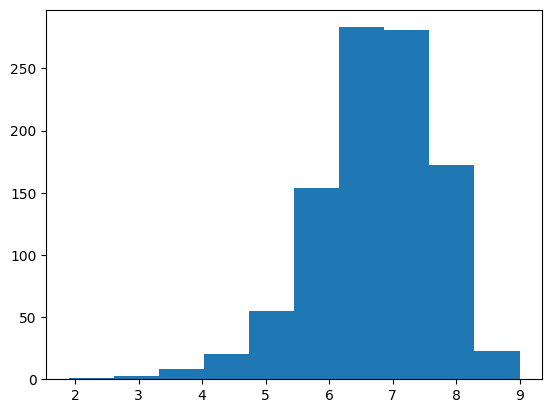

In [ ]:
plt.hist(df.Rating)

### 17. Vuelve a describir el dataframe y observa la media de la variable `Ratings`

In [ ]:
df.describe.Rating.mean()


np.float64(6.723199999999999)

### 18. Calcula este promedio con Numpy y después con un método de Pandas

In [ ]:
import numpy as np
df.Rating.mean()
np.mean(df.Rating)

np.float64(6.814319809069212)

### 19. Obten los valores únicos de la variable Rating y después ordénalos de menor a mayor

In [ ]:
df.Rating.ascending = True
df.Rating.head()

0    8.1
1    7.0
2    7.3
3    7.2
4    6.2
Name: Rating, dtype: float64

### 20. Observa los ratings que te interesen y ahora filtra el dataframe con ese rating para ver cuáles son las películas con dicho rating

In [ ]:
print(df['Rating'] > df['Rating'].mean())

0       True
1       True
2       True
3       True
4      False
       ...  
993    False
994    False
996    False
997    False
999    False
Name: Rating, Length: 838, dtype: bool


### 21. Obten los valores únicos de la variable Rating y la frecuencia total de cada uno de estos valores. Posteriormente crea un nuevo dataframe con essos valores

In [ ]:
Frecuencias = df['Rating'].value_counts()

df_rating = pd.DataFrame({
    'Rating': Frecuencias.index,
    'Frecuencia': Frecuencias.values
})

df_rating.head()




,Rating,Frecuencia
0,7.1,52
1,6.7,48
2,7.0,46
3,6.3,44
4,7.3,42


### 22. Ordena el nuevo dataframe por la variable `rating`

In [ ]:
df_rating = df_rating.sort_values('Frecuencia', ascending=True)
df_rating.head()


,Rating,Frecuencia
52,4.5,1
48,9.0,1
50,4.0,1
49,4.1,1
54,4.4,1


### 23. Crea una gráfica de barras con este nuevo dataframe ordenado

<Axes: ylabel='Rating'>

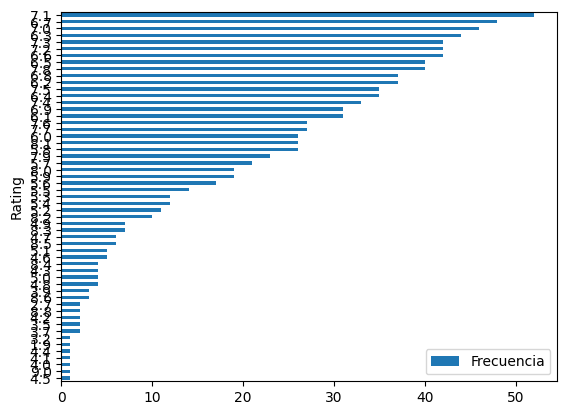

In [ ]:
df_rating.plot.barh (x='Rating', y='Frecuencia' )
  


### 24. Crea la matriz de correlación del dataframe de películas

In [ ]:
df.corr(numeric_only=True)

,Rank,Year,Runtime_minutes,Rating,Votes,Revenue_millions,Metascore
Rank,1.000000,-0.261605,-0.221739,-0.219555,-0.283876,-0.271592,-0.191869
Year,-0.261605,1.000000,-0.164900,-0.211219,-0.411904,-0.126790,-0.079305
Runtime_minutes,-0.221739,-0.164900,1.000000,0.392214,0.407062,0.267953,0.211978
Rating,-0.219555,-0.211219,0.392214,1.000000,0.511537,0.217654,0.631897
Votes,-0.283876,-0.411904,0.407062,0.511537,1.000000,0.639661,0.325684
Revenue_millions,-0.271592,-0.126790,0.267953,0.217654,0.639661,1.000000,0.142397
Metascore,-0.191869,-0.079305,0.211978,0.631897,0.325684,0.142397,1.000000


### 25. Grafica la matriz de correlación utilizando `matshow()`

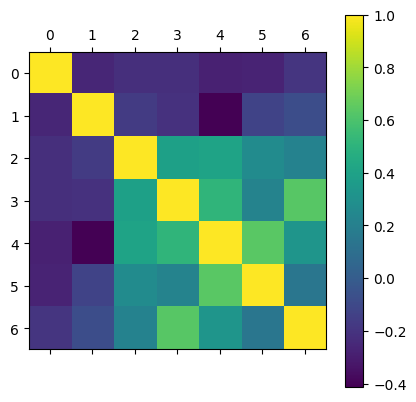

In [ ]:
matshow = df.corr(numeric_only=True)
plt.matshow(matshow)
plt.colorbar()
